# Scene Path Index Notebook

Goal: load a scene, inspect road vertex indices, and create `path_indices` manually.

In [1]:
import numpy as np
from pathlib import Path
from sionna.rt import load_scene
from utils import get_object_vertices, plot_vertices_index, plot_path_from_indices, prepare_path_data

np.set_printoptions(precision=3, suppress=True)

In [ ]:
# 1) Configure scene/object
XML_PATH = Path('/data/hw/sionna/workspace/scenes/etri_0226/etri_260226_fixed.xml')  # change if needed
MERGE_SHAPES = False
ROAD_OBJECT_ID = 'car'  # update after checking candidates

# Path setup (after selecting path indices)
PATH_INDICES = [1, 14, 0, 12, 10, 8, 5, 4]  # manual input
Z_OFFSET = 1.5
SPEED_MS = 10.0
DELTA_T = 0.1

print('XML_PATH =', XML_PATH)
print('ROAD_OBJECT_ID =', ROAD_OBJECT_ID)

XML_PATH = /data/hw/sionna/workspace/scenes/etri_0226/etri_260226_fixed.xml
ROAD_OBJECT_ID = car


In [4]:
# 2) Load scene
if not XML_PATH.exists():
    raise FileNotFoundError(f'Scene XML not found: {XML_PATH.resolve()}')

scene = load_scene(str(XML_PATH), merge_shapes=MERGE_SHAPES)
print('Scene loaded from:', XML_PATH.resolve())
print('num objects =', len(scene.objects))

Scene loaded from: /data/hw/sionna/workspace/scenes/etri_0226/etri_260226_fixed.xml
num objects = 8


In [5]:
# 3) Inspect object names and choose ROAD_OBJECT_ID
all_object_names = list(scene.objects.keys())
road_like = [
    n for n in all_object_names
    if any(k in n.lower() for k in ['road', 'path', 'street', 'lane'])
]

print('--- road-like candidates ---')
for n in road_like[:200]:
    print(n)

print('\n--- first 60 object names ---')
for n in all_object_names[:60]:
    print(n)


--- road-like candidates ---

--- first 60 object names ---
elm__2
elm__3
mountain0
mountain1
elm__7
elm__9
car
uav


In [6]:
# 4) Extract road vertices
road_positions = get_object_vertices(scene, ROAD_OBJECT_ID, round_decimals=3)
print('road_positions shape =', road_positions.shape)
print('first 5 rows:\n', road_positions[:5])

road_positions shape = (16, 3)
first 5 rows:
 [[ -85.715 -160.815    0.3  ]
 [ -97.653 -168.273    0.3  ]
 [ -95.533 -171.666    0.3  ]
 [ -83.595 -164.207    0.3  ]
 [ -57.508   55.699    0.3  ]]


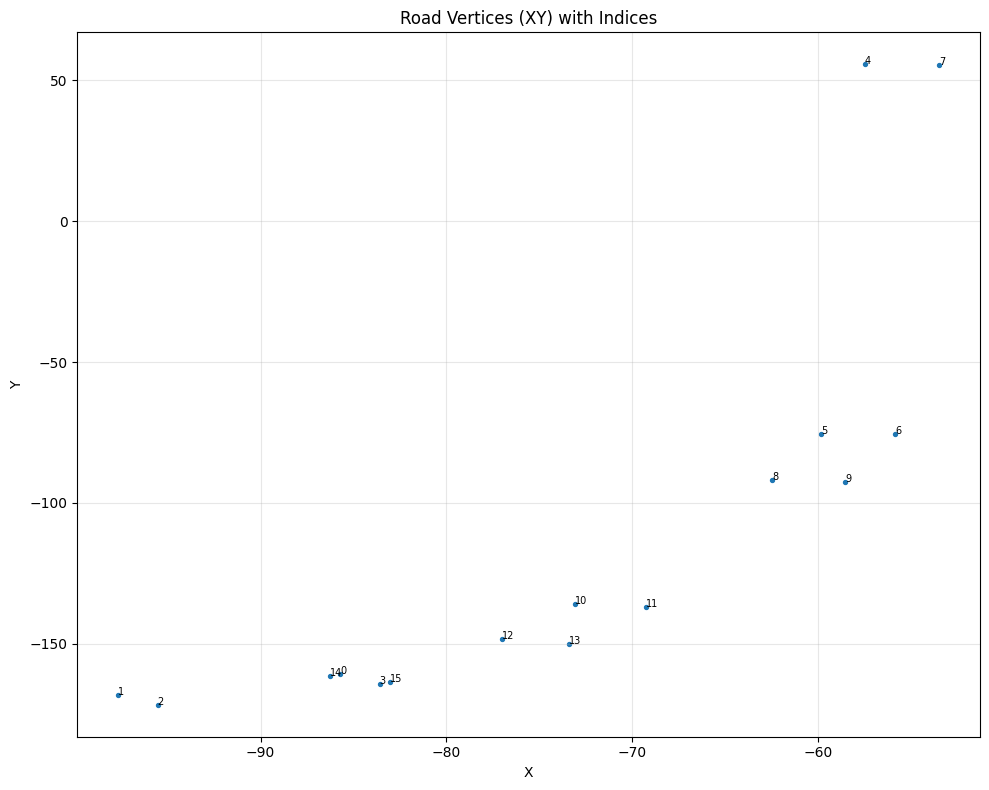

In [7]:
# 5) Plot index map and read indices manually
plot_vertices_index(road_positions, figsize=(10, 8), marker_size=8)

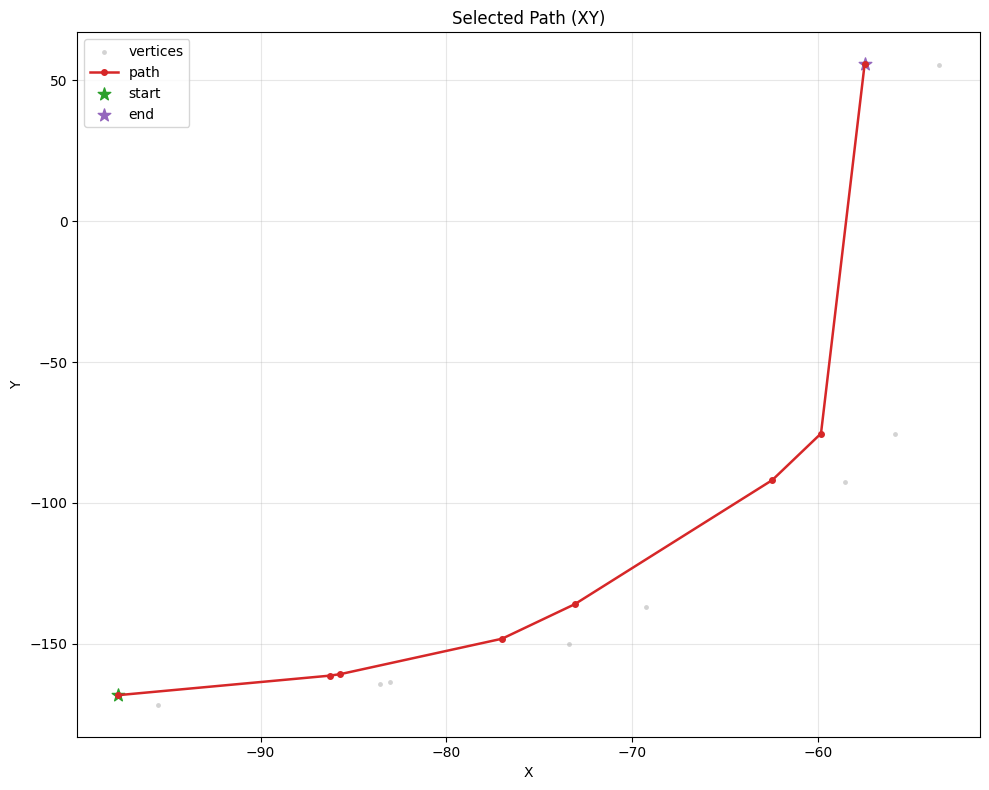

path_indices = [1, 14, 0, 12, 10, 8, 5, 4]


In [ ]:
PATH_INDICES = [1, 14, 0, 12, 10, 8, 5, 4]

# 6) Enter PATH_INDICES manually and check selected path
path_indices = np.asarray(PATH_INDICES, dtype=np.int32)
if np.any(path_indices < 0) or np.any(path_indices >= len(road_positions)):
    raise ValueError('PATH_INDICES includes out-of-range index.')

plot_path_from_indices(road_positions, path_indices, figsize=(10, 8))
print('PATH_INDICES =', path_indices.tolist())

In [10]:
# 7) Build path_data and inspect key info
path_data = prepare_path_data(
    road_positions=road_positions,
    path_indices=path_indices,
    z_offset=Z_OFFSET,
    speed_ms=SPEED_MS,
    delta_t=DELTA_T,
)

print('total_distance [m] =', path_data['total_distance'])
print('total_time [s] =', path_data['total_time'])
print('num_frames =', len(path_data['frame_times']))
print('waypoints shape =', path_data['waypoints'].shape)
print('frame_times (first 10) =', path_data['frame_times'][:10])

total_distance [m] = 235.42364501953125
total_time [s] = 23.542364501953124
num_frames = 237
waypoints shape = (8, 3)
frame_times (first 10) = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
